<a href="https://colab.research.google.com/github/2873991-Manthena/Dissertation/blob/main/DistillBert_with_Raw_Datatset_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###############################################################
# SECTION 1 - INSTALL LIBRARIES
###############################################################

!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00


In [ ]:
###############################################################
# SECTION 2 - IMPORT LIBRARIES
###############################################################

import pandas as pd
import numpy as np
import evaluate
import torch

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
###############################################################
# SECTION 3 - MOUNT GOOGLE DRIVE
###############################################################

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
###############################################################
# SECTION 4 - DATASET PATH
###############################################################

DATASET_PATH = "/content/drive/MyDrive/Dissertation/mbti_1 raw.csv"

In [ ]:
###############################################################
# SECTION 5 - LOAD RAW DATASET
###############################################################

df = pd.read_csv(DATASET_PATH)

print("Dataset Shape:", df.shape)
display(df.head())

print(df.columns)

Dataset Shape: (8675, 2)


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


Index(['type', 'posts'], dtype='object')


In [ ]:
###############################################################
# COMPUTE METRICS
###############################################################

import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "precision": precision.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["precision"],

        "recall": recall.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["recall"],

        "f1": f1.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["f1"],
    }

In [ ]:
print(df.columns)

Index(['type', 'posts'], dtype='object')


In [ ]:
###############################################################
# SECTION 6 - DATA PREPARATION
###############################################################

df = df[['type', 'posts']]

df.dropna(inplace=True)

df['posts'] = df['posts'].astype(str)

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB
None


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
###############################################################
# SECTION 6 - DATA PREPARATION
###############################################################

# Keep only required columns
df = df[['type', 'posts']]

# Remove missing values
df.dropna(inplace=True)

# Convert to string
df['posts'] = df['posts'].astype(str)

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    8675 non-null   object
 1   posts   8675 non-null   object
dtypes: object(2)
memory usage: 135.7+ KB
None


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
###############################################################
# SECTION 7 - LABEL ENCODING
###############################################################

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["type"])

print(label_encoder.classes_)

['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


In [ ]:
###############################################################
# SECTION 8 - TRAIN TEST SPLIT
###############################################################

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (6940, 3)
Testing Shape: (1735, 3)


In [ ]:
###############################################################
# SECTION 9 - LOAD TOKENIZER
###############################################################

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
###############################################################
# SECTION 10 - CREATE DATASETS
###############################################################

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[['posts', 'label']],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[['posts', 'label']],
    preserve_index=False
)

In [ ]:
###############################################################
# SECTION 11 - TOKENIZATION
###############################################################

def tokenize(batch):

    return tokenizer(
        batch["posts"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6940 [00:00<?, ? examples/s]

Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

In [ ]:
###############################################################
# SECTION 12 - RENAME LABEL COLUMN
###############################################################

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [ ]:
###############################################################
# SECTION 13 - REMOVE POSTS COLUMN
###############################################################

train_dataset = train_dataset.remove_columns(["posts"])
test_dataset = test_dataset.remove_columns(["posts"])

In [ ]:
###############################################################
# SECTION 14 - SET FORMAT
###############################################################

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
###############################################################
# SECTION 15 - LOAD MODEL
###############################################################

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
###############################################################
# SECTION 16 - TRAINING ARGUMENTS
###############################################################

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_dir="./logs",

    logging_steps=100,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
###############################################################
# SECTION 17 - TRAINER
###############################################################

from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
###############################################################
# FIX TORCHVISION / VIDEOREADER ISSUE
###############################################################

!pip uninstall -y torchvision

Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu


In [ ]:
###############################################################
# SECTION 18 - TRAIN MODEL
###############################################################

trainer.train()

In [ ]:
###############################################################
# SECTION 19 - FINAL EVALUATION
###############################################################

results = trainer.evaluate()

print("\n===== FINAL EVALUATION =====")

for key, value in results.items():
    print(f"{key}: {value}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.275983,1.794873,5,0.470893,0.472054,0.470893,0.462610



===== FINAL EVALUATION =====
eval_loss: 1.7948733568191528
eval_accuracy: 0.47089337175792506
eval_precision: 0.4720543077989431
eval_recall: 0.47089337175792506
eval_f1: 0.46261038000863425


In [ ]:
###############################################################
# SECTION 20 - PREDICTIONS
###############################################################

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
###############################################################
# SECTION 21 - CLASSIFICATION REPORT
###############################################################

from sklearn.metrics import classification_report

print(

    classification_report(

        y_true,

        y_pred,

        target_names=label_encoder.classes_,

        digits=4

    )

)

              precision    recall  f1-score   support

        ENFJ     0.8182    0.2368    0.3673        38
        ENFP     0.5690    0.4889    0.5259       135
        ENTJ     0.3333    0.2826    0.3059        46
        ENTP     0.4392    0.4745    0.4561       137
        ESFJ     0.0000    0.0000    0.0000         9
        ESFP     0.0000    0.0000    0.0000        10
        ESTJ     0.0000    0.0000    0.0000         8
        ESTP     0.5556    0.2778    0.3704        18
        INFJ     0.4942    0.4354    0.4629       294
        INFP     0.4466    0.6175    0.5183       366
        INTJ     0.5169    0.4908    0.5035       218
        INTP     0.4618    0.5096    0.4845       261
        ISFJ     0.5000    0.4848    0.4923        33
        ISFP     0.4412    0.2778    0.3409        54
        ISTJ     0.4400    0.2683    0.3333        41
        ISTP     0.3770    0.3433    0.3594        67

    accuracy                         0.4709      1735
   macro avg     0.3996   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


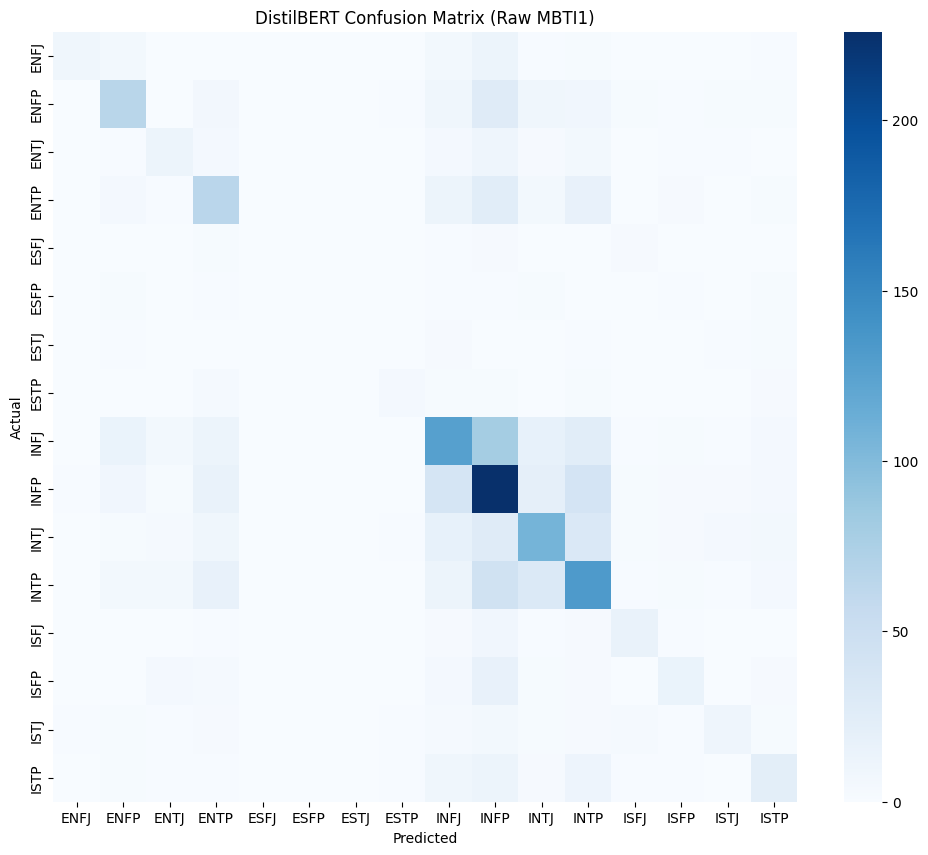

In [ ]:
###############################################################
# SECTION 22 - CONFUSION MATRIX
###############################################################

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix (Raw MBTI1)")

plt.show()

In [ ]:
###############################################################
# SECTION 23 - SAVE RESULTS
###############################################################

results_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[

        results["eval_accuracy"],

        results["eval_precision"],

        results["eval_recall"],

        results["eval_f1"]

    ]

})

results_df.to_csv(

    "/content/drive/MyDrive/Dissertation/DistilBERT_MBTI1_RAW_Results.csv",

    index=False

)

print("Results Saved Successfully!")

Results Saved Successfully!


In [ ]:
###############################################################
# DIAGNOSTIC - RAW MBTI1 DISTILBERT
###############################################################

print("===== DATA =====")
print("Dataset shape:", df.shape)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\n===== LABELS =====")
print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

print("\n===== MODEL =====")
print("Number of model labels:", model.config.num_labels)

print("\n===== TRUE LABEL DISTRIBUTION =====")
print(pd.Series(y_true).value_counts().sort_index())

print("\n===== PREDICTED LABEL DISTRIBUTION =====")
print(pd.Series(y_pred).value_counts().sort_index())

print("\n===== LABEL MAPPING =====")
for i, label in enumerate(label_encoder.classes_):
    print(i, "->", label)

===== DATA =====
Dataset shape: (8675, 3)
Train shape: (6940, 3)
Test shape: (1735, 3)

===== LABELS =====
Number of classes: 16
Classes: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']

===== MODEL =====
Number of model labels: 16

===== TRUE LABEL DISTRIBUTION =====
0      38
1     135
2      46
3     137
4       9
5      10
6       8
7      18
8     294
9     366
10    218
11    261
12     33
13     54
14     41
15     67
Name: count, dtype: int64

===== PREDICTED LABEL DISTRIBUTION =====
0      11
1     116
2      39
3     148
7       9
8     259
9     506
10    207
11    288
12     32
13     34
14     25
15     61
Name: count, dtype: int64

===== LABEL MAPPING =====
0 -> ENFJ
1 -> ENFP
2 -> ENTJ
3 -> ENTP
4 -> ESFJ
5 -> ESFP
6 -> ESTJ
7 -> ESTP
8 -> INFJ
9 -> INFP
10 -> INTJ
11 -> INTP
12 -> ISFJ
13 -> ISFP
14 -> ISTJ
15 -> ISTP


In [ ]:
print("\n===== MODEL =====")
print("Number of model labels:", model.config.num_labels)

print("\n===== TRUE LABEL DISTRIBUTION =====")
print(pd.Series(y_true).value_counts().sort_index())

print("\n===== PREDICTED LABEL DISTRIBUTION =====")
print(pd.Series(y_pred).value_counts().sort_index())

print("\n===== LABEL MAPPING =====")
for i, label in enumerate(label_encoder.classes_):
    print(i, "->", label)


===== MODEL =====
Number of model labels: 16

===== TRUE LABEL DISTRIBUTION =====
0      38
1     135
2      46
3     137
4       9
5      10
6       8
7      18
8     294
9     366
10    218
11    261
12     33
13     54
14     41
15     67
Name: count, dtype: int64

===== PREDICTED LABEL DISTRIBUTION =====
0      11
1     116
2      39
3     148
7       9
8     259
9     506
10    207
11    288
12     32
13     34
14     25
15     61
Name: count, dtype: int64

===== LABEL MAPPING =====
0 -> ENFJ
1 -> ENFP
2 -> ENTJ
3 -> ENTP
4 -> ESFJ
5 -> ESFP
6 -> ESTJ
7 -> ESTP
8 -> INFJ
9 -> INFP
10 -> INTJ
11 -> INTP
12 -> ISFJ
13 -> ISFP
14 -> ISTJ
15 -> ISTP


In [ ]:
###############################################################
# MBTI500 RAW - DATASET PATH
###############################################################

MBTI500_PATH = "/content/drive/MyDrive/Dissertation/MBTI 500 raw.csv"

In [ ]:
###############################################################
# MBTI500 RAW - LOAD DATASET
###############################################################

df500 = pd.read_csv(MBTI500_PATH)

print("Dataset Shape:", df500.shape)
print("Columns:", df500.columns.tolist())

display(df500.head())

Dataset Shape: (106067, 2)
Columns: ['posts', 'type']


,posts,type
0,know intj tool use interaction people excuse a...,INTJ
1,rap music ehh opp yeah know valid well know fa...,INTJ
2,preferably p hd low except wew lad video p min...,INTJ
3,drink like wish could drink red wine give head...,INTJ
4,space program ah bad deal meing freelance max ...,INTJ


In [ ]:
###############################################################
# MBTI500 RAW - DATA PREPARATION
###############################################################

df500 = df500[["type", "posts"]].copy()
df500.dropna(subset=["type", "posts"], inplace=True)
df500["posts"] = df500["posts"].astype(str)

print("Shape:", df500.shape)

Shape: (106067, 2)


In [ ]:
###############################################################
# LABEL ENCODING
###############################################################

label_encoder500 = LabelEncoder()

df500["label"] = label_encoder500.fit_transform(df500["type"])

print("Classes:", label_encoder500.classes_)
print("Number of classes:", len(label_encoder500.classes_))

Classes: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']
Number of classes: 16


In [ ]:
###############################################################
# TRAIN TEST SPLIT
###############################################################

train_df500, test_df500 = train_test_split(
    df500,
    test_size=0.20,
    random_state=42,
    stratify=df500["label"]
)

print("Train:", train_df500.shape)
print("Test:", test_df500.shape)

Train: (84853, 3)
Test: (21214, 3)


In [ ]:
###############################################################
# HUGGING FACE DATASETS
###############################################################

train_dataset500 = Dataset.from_pandas(
    train_df500[["posts", "label"]],
    preserve_index=False
)

test_dataset500 = Dataset.from_pandas(
    test_df500[["posts", "label"]],
    preserve_index=False
)

In [ ]:
###############################################################
# TOKENIZATION
###############################################################

def tokenize500(batch):
    return tokenizer(
        batch["posts"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset500 = train_dataset500.map(
    tokenize500,
    batched=True
)

test_dataset500 = test_dataset500.map(
    tokenize500,
    batched=True
)

Map:   0%|          | 0/84853 [00:00<?, ? examples/s]

Map:   0%|          | 0/21214 [00:00<?, ? examples/s]

In [ ]:
###############################################################
# FORMAT DATASETS
###############################################################

train_dataset500 = train_dataset500.rename_column(
    "label", "labels"
)

test_dataset500 = test_dataset500.rename_column(
    "label", "labels"
)

train_dataset500 = train_dataset500.remove_columns(["posts"])
test_dataset500 = test_dataset500.remove_columns(["posts"])

train_dataset500.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset500.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [ ]:
###############################################################
# FRESH DISTILBERT MODEL
###############################################################

model500 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=16
)

print("Model labels:", model500.config.num_labels)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model labels: 16


In [ ]:
###############################################################
# TRAINING ARGUMENTS
###############################################################

training_args500 = TrainingArguments(
    output_dir="./results_mbti500_raw",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    report_to="none"
)

In [ ]:
###############################################################
# TRAINER
###############################################################

trainer500 = Trainer(
    model=model500,
    args=training_args500,
    train_dataset=train_dataset500,
    eval_dataset=test_dataset500,
    compute_metrics=compute_metrics
)

In [ ]:
###############################################################
# TRAIN MBTI500 RAW DISTILBERT
###############################################################

trainer500.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.002297,1.048987,0.662864,0.678584,0.662864,0.664147
2,0.880067,0.953036,0.700575,0.703847,0.700575,0.700079
3,0.719363,0.946975,0.703733,0.705974,0.703733,0.702541
4,0.632778,0.988568,0.704912,0.706056,0.704912,0.704604
5,0.492102,1.038443,0.701424,0.701497,0.701424,0.700814


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=26520, training_loss=0.7983732686323278, metrics={'train_runtime': 9507.183, 'train_samples_per_second': 44.626, 'train_steps_per_second': 2.789, 'total_flos': 2.810765633581056e+16, 'train_loss': 0.7983732686323278, 'epoch': 5.0})

In [ ]:
###############################################################
# FINAL EVALUATION
###############################################################

results500 = trainer500.evaluate()

print("\n===== MBTI500 RAW FINAL RESULTS =====")

print("Accuracy :", results500["eval_accuracy"])
print("Precision:", results500["eval_precision"])
print("Recall   :", results500["eval_recall"])
print("F1 Score :", results500["eval_f1"])

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.492102,0.988568,5,0.704912,0.706056,0.704912,0.704604



===== MBTI500 RAW FINAL RESULTS =====
Accuracy : 0.7049118506646554
Precision: 0.7060560178569361
Recall   : 0.7049118506646554
F1 Score : 0.7046035378918822


In [ ]:
###############################################################
# SAVE RESULTS
###############################################################

results500_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        results500["eval_accuracy"],
        results500["eval_precision"],
        results500["eval_recall"],
        results500["eval_f1"]
    ]
})

results500_df.to_csv(
    "/content/drive/MyDrive/Dissertation/DistilBERT_MBTI500_RAW_Results.csv",
    index=False
)

print(" MBTI500 RAW results saved!")

✅ MBTI500 RAW results saved!


In [ ]:
###############################################################
# LOAD COMBINED RAW DATASETS
###############################################################

MBTI1_RAW_PATH = "/content/drive/MyDrive/Dissertation/mbti_1 raw.csv"

MBTI500_RAW_PATH = "/content/drive/MyDrive/Dissertation/MBTI 500 raw.csv"

df_raw1 = pd.read_csv(MBTI1_RAW_PATH)
df_raw500 = pd.read_csv(MBTI500_RAW_PATH)

print("===== MBTI1 RAW =====")
print("Shape:", df_raw1.shape)
print("Columns:", df_raw1.columns.tolist())

print("\n===== MBTI500 RAW =====")
print("Shape:", df_raw500.shape)
print("Columns:", df_raw500.columns.tolist())

===== MBTI1 RAW =====
Shape: (8675, 2)
Columns: ['type', 'posts']

===== MBTI500 RAW =====
Shape: (106067, 2)
Columns: ['posts', 'type']


In [ ]:
###############################################################
# PREPARE RAW DATA
###############################################################

df_raw1 = df_raw1[["type", "posts"]].dropna().copy()
df_raw500 = df_raw500[["type", "posts"]].dropna().copy()

df_raw1["posts"] = df_raw1["posts"].astype(str)
df_raw500["posts"] = df_raw500["posts"].astype(str)

print("MBTI1:", df_raw1.shape)
print("MBTI500:", df_raw500.shape)

MBTI1: (8675, 2)
MBTI500: (106067, 2)


In [ ]:
###############################################################
# COMBINE MBTI1 + MBTI500 RAW
###############################################################

combined_raw = pd.concat(
    [df_raw1, df_raw500],
    ignore_index=True
)

print("===== COMBINED RAW =====")
print("Shape:", combined_raw.shape)

display(combined_raw.head())

===== COMBINED RAW =====
Shape: (114742, 2)


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
###############################################################
# LABEL ENCODING
###############################################################

label_encoder = LabelEncoder()

combined_raw["label"] = label_encoder.fit_transform(
    combined_raw["type"]
)

print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

Number of classes: 16
Classes: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


In [ ]:
###############################################################
# TRAIN TEST SPLIT
###############################################################

train_df, test_df = train_test_split(
    combined_raw,
    test_size=0.20,
    random_state=42,
    stratify=combined_raw["label"]
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (91793, 3)
Test : (22949, 3)


In [ ]:
###############################################################
# COMBINED RAW - HUGGING FACE DATASETS
###############################################################

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["posts", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["posts", "label"]],
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['posts', 'label'],
    num_rows: 91793
})
Dataset({
    features: ['posts', 'label'],
    num_rows: 22949
})


In [ ]:
###############################################################
# DISTILBERT TOKENIZER
###############################################################

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("✅ Tokenizer loaded")

✅ Tokenizer loaded


In [ ]:
###############################################################
# TOKENIZE COMBINED RAW POSTS
###############################################################

def tokenize_raw(batch):
    return tokenizer(
        batch["posts"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(
    tokenize_raw,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_raw,
    batched=True
)

print("✅ Tokenization complete")

Map:   0%|          | 0/91793 [00:00<?, ? examples/s]

Map:   0%|          | 0/22949 [00:00<?, ? examples/s]

✅ Tokenization complete


In [ ]:
###############################################################
# FORMAT DATASETS
###############################################################

train_dataset = train_dataset.rename_column(
    "label", "labels"
)

test_dataset = test_dataset.rename_column(
    "label", "labels"
)

train_dataset = train_dataset.remove_columns(
    ["posts"]
)

test_dataset = test_dataset.remove_columns(
    ["posts"]
)

train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 91793
})


In [ ]:
###############################################################
# METRICS
###############################################################

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    }

In [ ]:
###############################################################
# FRESH DISTILBERT MODEL
###############################################################

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=16
)

print("✅ DistilBERT loaded")
print("Labels:", model.config.num_labels)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT loaded
Labels: 16


In [ ]:
###############################################################
# TRAINING ARGUMENTS
###############################################################

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Dissertation/DistilBERT_Combined_RAW",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    logging_steps=100,

    report_to="none"
)

In [ ]:
###############################################################
# TRAINER
###############################################################

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("✅ Trainer ready")

✅ Trainer ready


In [ ]:
import os

print(
    "Existing checkpoints:",
    os.listdir(
        "/content/drive/MyDrive/Dissertation/DistilBERT_Combined_RAW"
    )
    if os.path.exists(
        "/content/drive/MyDrive/Dissertation/DistilBERT_Combined_RAW"
    )
    else "None"
)

Existing checkpoints: ['checkpoint-5738', 'checkpoint-11476', 'checkpoint-17214']


In [ ]:
###############################################################
# FIX TORCHVISION / DATASETS COMPATIBILITY
###############################################################

!pip uninstall -y torchvision -q

In [ ]:
import sys

if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

print("✅ torchvision removed")

✅ torchvision removed


In [ ]:
###############################################################
# START COMBINED RAW DISTILBERT TRAINING
###############################################################

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
